In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
file_path = "Credit Card Data.xlsx"
customer = pd.read_excel(file_path, sheet_name="Customer Acqusition")
spend = pd.read_excel(file_path, sheet_name="Spend")
repayment = pd.read_excel(file_path, sheet_name="Repayment")
                          
print("Customer Acquisition Data")
display(customer.head())
print("Spend Data")
display(spend.head())
print("Repayment Data")
display(repayment.head())

Customer Acquisition Data


,No,Customer,Age,City,Product,Limit,Company,Segment
0,1,A1,34.012349,BANGALORE,Gold,500000,C1,Self Employed
1,2,A2,50.497350,CALCUTTA,Silver,100000,C2,Salaried_MNC
2,3,A3,35.855817,COCHIN,Platimum,10000,C3,Salaried_Pvt
3,4,A4,27.356821,BOMBAY,Platimum,10001,C4,Govt
4,5,A5,22.021249,BANGALORE,Platimum,10002,C5,Normal Salary


Spend Data


,Sl No:,Customer,Month,Type,Amount
0,1,A1,2004-01-12,JEWELLERY,344054.980813
1,2,A1,2004-01-03,PETRO,467747.601626
2,3,A1,2004-01-15,CLOTHES,86878.954735
3,4,A1,2004-01-25,FOOD,269175.011875
4,5,A1,2005-01-17,CAMERA,3406.639477


Repayment Data


,SL No:,Customer,Month,Amount
0,1,A1,2004-01-12,338932.141919
1,2,A1,2004-01-03,131778.688758
2,3,A1,2004-01-15,485981.516736
3,4,A1,2004-01-25,452865.826385
4,5,A1,2005-01-17,154684.838196


In [5]:
#1(a) Replace age below 18 with mean age
#Mean Age
mean_age = customer["Age"].mean()
print("Mean age before replacement:", mean_age)
print("Number of customers below 18:",
      (customer["Age"] < 18).sum())
customer.loc[customer["Age"] < 18, "Age"] = mean_age
print("\nMean age used for replacement:", mean_age)
print("Minimum age after replacement:", customer["Age"].min())


Mean age before replacement: 37.46184743226689
Number of customers below 18: 25

Mean age used for replacement: 37.46184743226689
Minimum age after replacement: 18.00587827577454


In [6]:
#1(b) Replace spend amount if it exceeds customer's limit
spend = spend.merge(
    customer[["Customer", "Limit"]],
    on="Customer",
    how="left"
)
print("Transactions where spend exceeds limit:",
      (spend["Amount"] > spend["Limit"]).sum())
spend.loc[
    spend["Amount"] > spend["Limit"],
    "Amount"
] = spend.loc[
    spend["Amount"] > spend["Limit"],
    "Limit"
] * 0.50
print("Transactions exceeding limit after cleaning:",
      (spend["Amount"] > spend["Limit"]).sum())

Transactions where spend exceeds limit: 591
Transactions exceeding limit after cleaning: 0


In [7]:
#1(c) Replace repayment if it exceeds customer's limit
repayment = repayment.merge(
    customer[["Customer", "Limit"]],
    on="Customer",
    how="left"
)
print("Repayments exceeding limit:",
      (repayment["Amount"] > repayment["Limit"]).sum())
repayment.loc[
    repayment["Amount"] > repayment["Limit"],
    "Amount"
] = repayment.loc[
    repayment["Amount"] > repayment["Limit"],
    "Limit"
]
print("Repayments exceeding limit after cleaning:",
      (repayment["Amount"] > repayment["Limit"]).sum())

Repayments exceeding limit: 604
Repayments exceeding limit after cleaning: 0


In [8]:
#2
# Month
spend["Month"] = pd.to_datetime(spend["Month"])
repayment["Month"] = pd.to_datetime(repayment["Month"])
#Year and Month
spend["Year"] = spend["Month"].dt.year
spend["Month_Year"] = spend["Month"].dt.to_period("M")
repayment["Year"] = repayment["Month"].dt.year
repayment["Month_Year"] = repayment["Month"].dt.to_period("M")

In [9]:
#2(a) How many distinct customers exist?
distinct_customers = customer["Customer"].nunique()
print("Number of distinct customers:", distinct_customers)

Number of distinct customers: 100


In [14]:
#2(b) How many distinct categories exist?
distinct_categories = spend["Type"].nunique()
print("Number of distinct categories:", distinct_categories)
print("Categories:")
print(spend["Type"].unique())

Number of distinct categories: 15
Categories:
['JEWELLERY' 'PETRO' 'CLOTHES' 'FOOD' 'CAMERA' 'SANDALS' 'CAR' 'BIKE'
 'AUTO' 'SHOPPING' 'AIR TICKET' 'BUS TICKET' 'TRAIN TICKET' 'RENTAL'
 'MOVIE TICKET']


In [15]:
#2(c) Average monthly spend by customers
monthly_spend = (
    spend
    .groupby("Month_Year")["Amount"]
    .sum()
)
average_monthly_spend = monthly_spend.mean()
print("Average monthly spend:",
      round(average_monthly_spend, 2))

Average monthly spend: 7624286.6


In [16]:
#2(d) Average monthly repayment by customers
monthly_repayment = (
    repayment
    .groupby("Month_Year")["Amount"]
    .sum()
)
average_monthly_repayment = monthly_repayment.mean()
print("Average monthly repayment:",
      round(average_monthly_repayment, 2))

Average monthly repayment: 8280252.03


In [19]:
#2(e) Profit for the bank for each month
monthly_profit = pd.concat(
    [monthly_spend, monthly_repayment],
    axis=1
)
monthly_profit.columns = ["Monthly_Spend", "Monthly_Repayment"]
monthly_profit = monthly_profit.fillna(0)
monthly_profit["Monthly_Profit"] = (
    monthly_profit["Monthly_Repayment"]
    - monthly_profit["Monthly_Spend"]
)
interest_rate = 0.029
monthly_profit["Bank_Profit"] = np.where(
    monthly_profit["Monthly_Profit"] > 0,
    monthly_profit["Monthly_Profit"] * interest_rate,
    0
)

display(monthly_profit.round(2))
total_bank_profit = monthly_profit["Bank_Profit"].sum()
print(f"Total Bank Profit = ₹{total_bank_profit:,.2f}")

,Monthly_Spend,Monthly_Repayment,Monthly_Profit,Bank_Profit
Month_Year,,,,
2004-01,46459874.72,45161919.58,-1297955.14,0.00
2004-02,4134085.15,4738437.51,604352.36,17526.22
2004-03,1254961.60,2811495.88,1556534.28,45139.49
2004-04,3833059.98,4226593.85,393533.87,11412.48
2004-05,2372873.66,3864227.20,1491353.54,43249.25
2004-09,1882803.99,2024091.45,141287.46,4097.34
2004-11,1967215.14,2276063.01,308847.87,8956.59
2005-01,4563799.79,5224097.16,660297.38,19148.62
2005-02,28239796.52,24180369.91,-4059426.61,0.00


Total Bank Profit = ₹929,363.00


In [20]:
#2(f) What are the top 5 product types?
top_5_products = (
    spend.groupby("Type")["Amount"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
)
print("Top 5 Product Types:")
display(top_5_products.to_frame("Total Spend"))

Top 5 Product Types:


,Total Spend
Type,
PETRO,3.106765e+07
CAMERA,2.864800e+07
FOOD,2.440443e+07
AIR TICKET,2.378068e+07
TRAIN TICKET,1.961041e+07


In [30]:
#2(g) Which city has maximum spend?
city = spend["Customer"].map(customer.set_index("Customer")["City"])
city_spend = spend.groupby(city)["Amount"].sum().sort_values(ascending=False)
print(city_spend)
print("City having maximum spend:", city_spend.idxmax())
print("Maximum spend:", city_spend.max())

Customer
COCHIN        4.857454e+07
BANGALORE     4.432235e+07
CALCUTTA      4.118221e+07
BOMBAY        3.069769e+07
CHENNAI       2.279110e+07
TRIVANDRUM    1.555818e+07
PATNA         1.311621e+07
DELHI         1.248631e+07
Name: Amount, dtype: float64
City having maximum spend: COCHIN
Maximum spend: 48574542.86290465


In [31]:
#2(h) — Which age group is spending more money?
spend_age = pd.merge(spend, customer[["Customer", "Age"]], on="Customer", how="left")
bins = [0, 18, 25, 35, 45, 55, 65, 100]
labels = ["<18", "18-25", "26-35", "36-45", "46-55", "56-65", "65+"]
spend_age["Age_Group"] = pd.cut(spend_age["Age"], bins=bins, labels=labels)
age_group_spend = spend_age.groupby("Age_Group", observed=True)["Amount"].sum().sort_values(ascending=False)
print(age_group_spend)
print("Age group spending more money:", age_group_spend.idxmax())
print("Maximum spend:", age_group_spend.max())


Age_Group
36-45    1.065063e+08
26-35    3.366143e+07
65+      3.112705e+07
46-55    2.722676e+07
56-65    1.875101e+07
18-25    1.145603e+07
Name: Amount, dtype: float64
Age group spending more money: 36-45
Maximum spend: 106506322.1143104


In [32]:
#2(i) — Who are the top 10 customers in terms of repayment?
top_10_customers = repayment.groupby("Customer")["Amount"].sum().sort_values(ascending=False).head(10)
print(top_10_customers)

Customer
A61    9.672794e+06
A60    9.168150e+06
A42    8.928473e+06
A13    8.496396e+06
A38    8.205337e+06
A43    7.976031e+06
A40    7.671796e+06
A14    7.655255e+06
A44    7.637482e+06
A26    7.472189e+06
Name: Amount, dtype: float64


          City   Product  Year        Amount
0    BANGALORE      Gold  2004  9.870697e+06
1    BANGALORE      Gold  2005  1.491447e+07
2    BANGALORE      Gold  2006  1.312135e+07
3    BANGALORE  Platimum  2004  1.045046e+06
4    BANGALORE  Platimum  2005  8.857226e+05
..         ...       ...   ...           ...
67  TRIVANDRUM  Platimum  2005  3.401179e+06
68  TRIVANDRUM  Platimum  2006  2.122722e+06
69  TRIVANDRUM    Silver  2004  2.729088e+05
70  TRIVANDRUM    Silver  2005  3.726143e+05
71  TRIVANDRUM    Silver  2006  5.335627e+05

[72 rows x 4 columns]


Product                  Gold      Platimum        Silver
City       Year                                          
BANGALORE  2004  9.870697e+06  1.045046e+06  1.215575e+06
           2005  1.491447e+07  8.857226e+05  9.090779e+05
           2006  1.312135e+07  7.096945e+05  1.650719e+06
BOMBAY     2004  6.221750e+06  9.469763e+05  5.186763e+05
           2005  9.533804e+06  8.360085e+05  5.727572e+05
           2006  1.019603e+07  1.022214e+06  8.494748e+05
CALCUTTA   2004  8.643979e+06  2.178863e+06  5.974884e+05
           2005  1.169198e+07  4.822990e+06  3.432595e+05
           2006  9.571088e+06  2.456412e+06  8.761541e+05
CHENNAI    2004  1.415073e+06  2.944115e+06  3.087747e+05
           2005  3.013081e+06  5.243051e+06  4.287585e+05
           2006  3.057966e+06  6.066896e+06  3.133881e+05
COCHIN     2004  9.730435e+06  2.974235e+06  7.891949e+05
           2005  1.102531e+07  4.151463e+06  6.437892e+05
           2006  1.262828e+07  5.530969e+06  1.100866e+06
DELHI      2004  3.467979e+06  3.388421e+05  8.040971e+05
           2005  2.508487e+06  4.436198e+05  4.934462e+05
           2006  3.535700e+06  1.333650e+05  7.607706e+05
PATNA      2004  1.915473e+06  8.166373e+05  8.448295e+05
           2005  2.187692e+06  2.534969e+06  9.494553e+05
           2006  2.424509e+06  7.453814e+05  6.972589e+05
TRIVANDRUM 2004  2.272700e+06  1.770528e+06  2.729088e+05
           2005  1.984571e+06  3.401179e+06  3.726143e+05
           2006  2.827397e+06  2.122722e+06  5.335627e+05

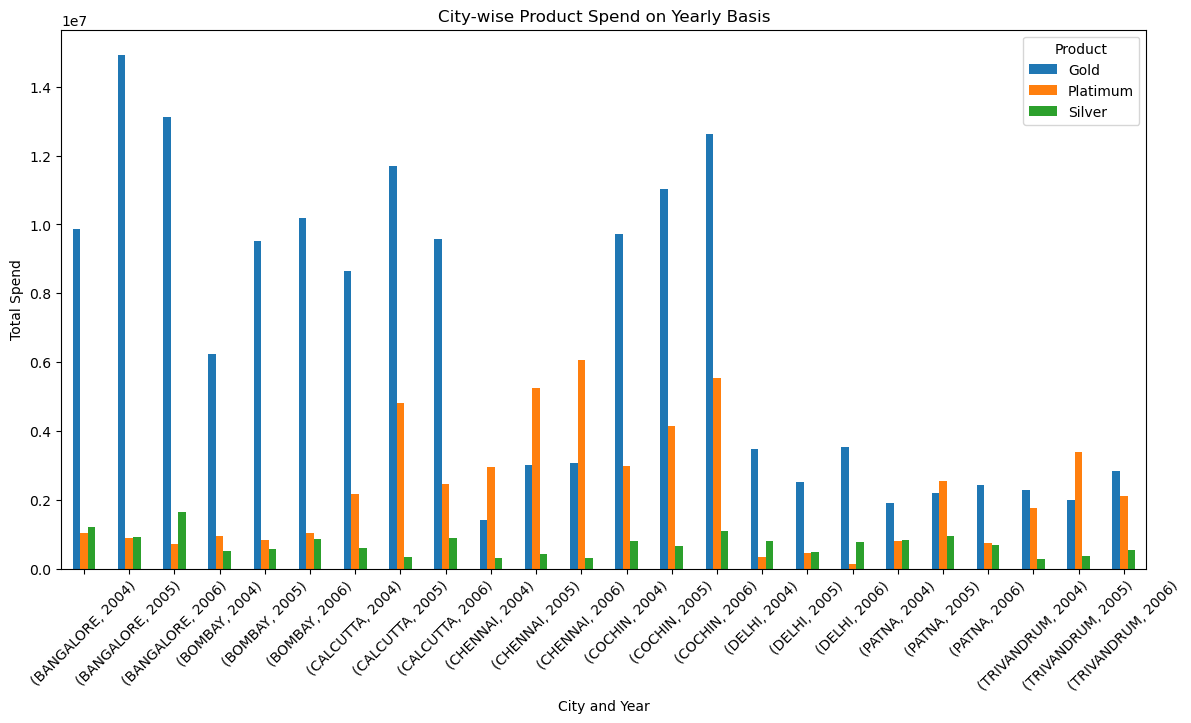

In [34]:
#3 — City-wise spend on each product on yearly basis + graphical representation
spend["Year"] = pd.to_datetime(spend["Month"]).dt.year
spend["City"] = spend["Customer"].map(
    customer.set_index("Customer")["City"])
spend["Product"] = spend["Customer"].map(
    customer.set_index("Customer")["Product"])
city_product_yearly = spend.groupby(
    ["City", "Product", "Year"]
)["Amount"].sum().reset_index()
print(city_product_yearly)
city_product_pivot = city_product_yearly.pivot_table(
    index=["City", "Year"],
    columns="Product",
    values="Amount",
    aggfunc="sum"
)
display(city_product_pivot)
city_product_pivot.plot(
    kind="bar",
    figsize=(14, 7)
)
plt.title("City-wise Product Spend on Yearly Basis")
plt.xlabel("City and Year")
plt.ylabel("Total Spend")
plt.xticks(rotation=45)
plt.legend(title="Product")
plt.show()

City,BANGALORE,BOMBAY,CALCUTTA,CHENNAI,COCHIN,DELHI,PATNA,TRIVANDRUM
Month,,,,,,,,
2004-01,8.684706e+06,5.204208e+06,8.754931e+06,4.381240e+06,1.048188e+07,2.587978e+06,3.246831e+06,3.118105e+06
2004-02,8.216525e+05,7.641748e+05,7.726826e+05,NaN,6.876862e+05,7.148190e+05,5.000100e+04,3.230690e+05
2004-03,5.500150e+04,5.771102e+04,4.677704e+05,1.731495e+04,2.589973e+05,3.481664e+05,5.000000e+04,NaN
2004-04,9.612245e+05,1.037605e+06,8.512640e+04,NaN,5.745281e+05,4.616039e+05,1.779142e+05,5.350575e+05
2004-05,1.020764e+06,5.000500e+03,3.401931e+05,2.868924e+04,6.686219e+05,5.000150e+04,5.219404e+04,2.074096e+05
2004-09,5.000000e+04,4.147815e+04,8.508654e+05,2.407181e+05,6.832244e+05,1.651786e+04,NaN,NaN
2004-11,5.379697e+05,5.772251e+05,1.487615e+05,NaN,1.389320e+05,4.318312e+05,NaN,1.324956e+05
2005-01,8.406639e+03,4.568651e+05,9.122929e+04,3.838859e+05,1.925958e+06,NaN,1.225866e+06,4.715880e+05
2005-02,8.248028e+06,2.991217e+06,5.612247e+06,2.831316e+06,3.694263e+06,8.696873e+05,1.491756e+06,2.501282e+06


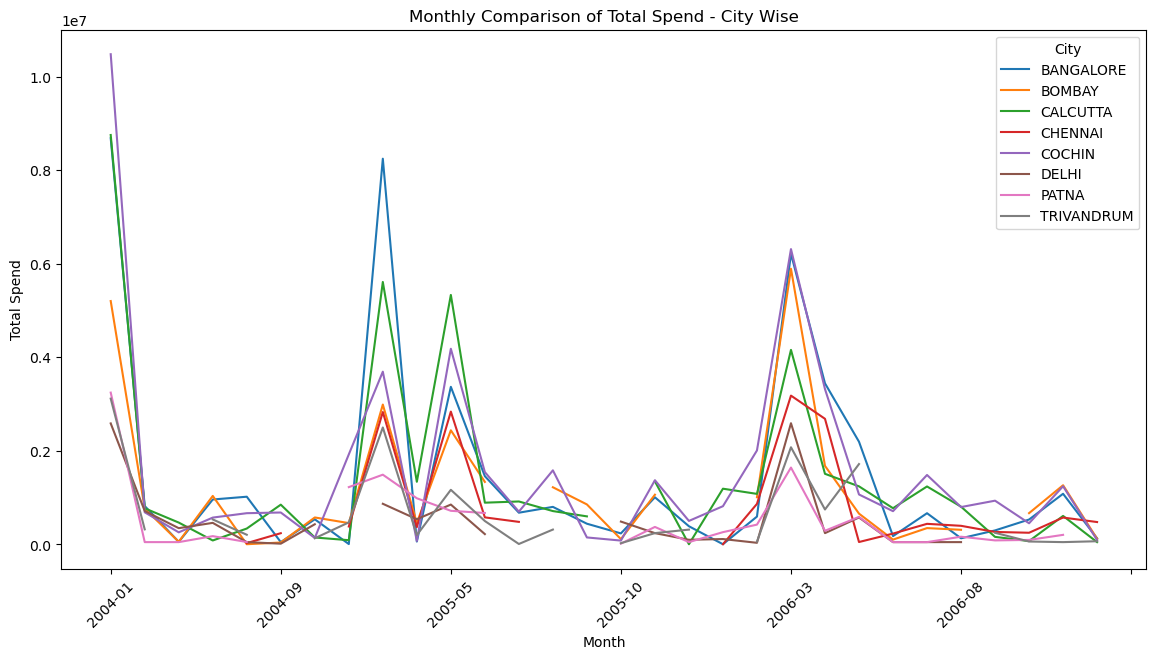

In [35]:
#4(a) — Monthly comparison of total spends, city wise
spend["Month"] = pd.to_datetime(spend["Month"])
spend["City"] = spend["Customer"].map(customer.set_index("Customer")["City"])
monthly_city_spend = spend.groupby(
    [spend["Month"].dt.to_period("M"), "City"]
)["Amount"].sum().reset_index()
monthly_city_spend["Month"] = monthly_city_spend["Month"].astype(str)
city_monthly_pivot = monthly_city_spend.pivot(
    index="Month",
    columns="City",
    values="Amount"
)
display(city_monthly_pivot)
city_monthly_pivot.plot(figsize=(14, 7))
plt.title("Monthly Comparison of Total Spend - City Wise")
plt.xlabel("Month")
plt.ylabel("Total Spend")
plt.xticks(rotation=45)
plt.legend(title="City")
plt.show()

Year
2004    5.565999e+06
2005    9.551944e+06
2006    8.662738e+06
Name: Amount, dtype: float64


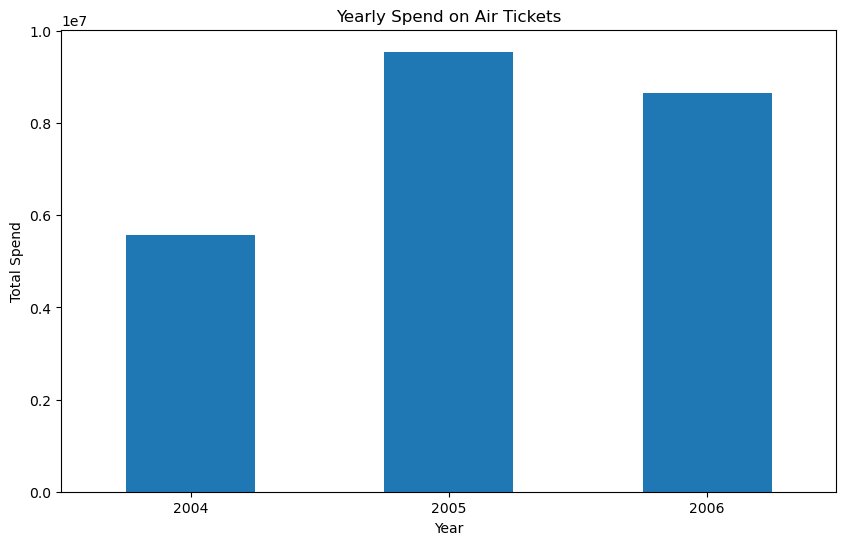

In [36]:
#4b — Comparison of yearly spend on air tickets
spend["Year"] = pd.to_datetime(spend["Month"]).dt.year
air_ticket_spend = spend[
    spend["Type"].str.lower().str.contains("air", na=False)
]
yearly_air_ticket = air_ticket_spend.groupby("Year")["Amount"].sum()
print(yearly_air_ticket)
yearly_air_ticket.plot(kind="bar", figsize=(10, 6))
plt.title("Yearly Spend on Air Tickets")
plt.xlabel("Year")
plt.ylabel("Total Spend")
plt.xticks(rotation=0)
plt.show()

Product,Gold,Platimum,Silver
Month,,,
2004-01,3.191020e+07,1.076281e+07,3.786862e+06
2004-02,3.479073e+06,3.550080e+05,3.000045e+05
2004-03,8.940277e+05,1.609324e+05,2.000015e+05
2004-04,3.130967e+06,2.594206e+05,4.426728e+05
2004-05,1.793554e+06,3.565282e+05,2.227916e+05
2004-09,9.079101e+05,8.583745e+05,1.165194e+05
2004-11,1.422352e+06,2.621710e+05,2.826925e+05
2005-01,2.580314e+06,1.704732e+06,2.787530e+05
2005-02,2.014734e+07,6.875153e+06,1.217300e+06


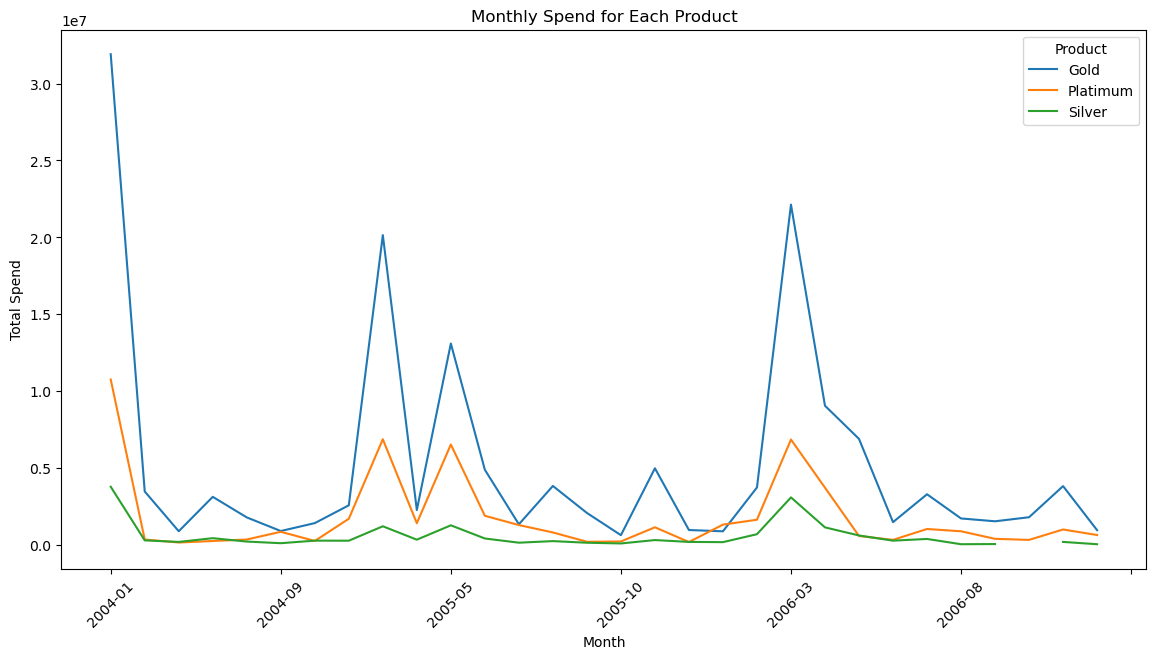

In [37]:
#4(c) — Monthly spend for each product
spend["Month"] = pd.to_datetime(spend["Month"])
monthly_product_spend = spend.groupby(
    [spend["Month"].dt.to_period("M"), "Product"]
)["Amount"].sum().reset_index()
monthly_product_spend["Month"] = monthly_product_spend["Month"].astype(str)
product_monthly_pivot = monthly_product_spend.pivot(
    index="Month",
    columns="Product",
    values="Amount"
)
display(product_monthly_pivot)
product_monthly_pivot.plot(figsize=(14, 7))
plt.title("Monthly Spend for Each Product")
plt.xlabel("Month")
plt.ylabel("Total Spend")
plt.xticks(rotation=45)
plt.legend(title="Product")
plt.show()

In [38]:
#5 — User-defined function for top 10 customers
# Q5

def top_10_customers(product, time_period):
    data = repayment.copy()
    data["Month"] = pd.to_datetime(data["Month"])
    data["Product"] = data["Customer"].map(
        customer.set_index("Customer")["Product"]
    )
    data["City"] = data["Customer"].map(
        customer.set_index("Customer")["City"]
    )
    data = data[data["Product"].str.lower() == product.lower()]
    if time_period.lower() == "yearly":
        data["Time_Period"] = data["Month"].dt.year   
    elif time_period.lower() == "monthly":
        data["Time_Period"] = data["Month"].dt.to_period("M")   
    else:
        print("Enter yearly or monthly")
        return
    result = data.groupby(
        ["City", "Time_Period", "Customer"]
    )["Amount"].sum().reset_index()
    result = result.sort_values(
        ["City", "Time_Period", "Amount"],
        ascending=[True, True, False]
    )
    result = result.groupby(
        ["City", "Time_Period"]
    ).head(10)
    return result

In [39]:
# Yearly Gold
result = top_10_customers("Gold", "yearly")
display(result)

,City,Time_Period,Customer,Amount
2,BANGALORE,2004,A14,2.471342e+06
1,BANGALORE,2004,A13,2.196412e+06
4,BANGALORE,2004,A43,2.083655e+06
0,BANGALORE,2004,A1,2.066125e+06
3,BANGALORE,2004,A30,1.493289e+06
...,...,...,...,...
83,PATNA,2006,A26,2.762535e+06
84,PATNA,2006,A66,2.684567e+05
85,TRIVANDRUM,2004,A28,1.710922e+06
86,TRIVANDRUM,2005,A28,2.265215e+06


In [40]:
#Monthly — Gold
result = top_10_customers("Gold", "monthly")
display(result)

,City,Time_Period,Customer,Amount
4,BANGALORE,2004-01,A43,2.083655e+06
0,BANGALORE,2004-01,A1,1.789635e+06
1,BANGALORE,2004-01,A13,1.441118e+06
2,BANGALORE,2004-01,A14,1.226087e+06
3,BANGALORE,2004-01,A30,5.644396e+05
...,...,...,...,...
300,TRIVANDRUM,2006-02,A28,4.511377e+05
301,TRIVANDRUM,2006-03,A28,1.209622e+06
302,TRIVANDRUM,2006-04,A28,3.208883e+04
303,TRIVANDRUM,2006-05,A28,8.932777e+05


In [41]:
#Yearly — Silver
result = top_10_customers("Silver", "yearly")
display(result)

,City,Time_Period,Customer,Amount
2,BANGALORE,2004,A59,5.628040e+05
1,BANGALORE,2004,A23,5.584056e+05
0,BANGALORE,2004,A18,5.100483e+05
3,BANGALORE,2004,A72,1.000000e+05
5,BANGALORE,2005,A23,8.093033e+05
4,BANGALORE,2005,A18,7.000000e+05
6,BANGALORE,2005,A59,5.809005e+05
7,BANGALORE,2005,A76,3.026389e+05
9,BANGALORE,2006,A23,8.740597e+05
8,BANGALORE,2006,A18,6.958613e+05


In [42]:
#Monthly — Silver
result = top_10_customers("Silver", "monthly")
display(result)

,City,Time_Period,Customer,Amount
2,BANGALORE,2004-01,A59,445846.512909
0,BANGALORE,2004-01,A18,414941.335845
1,BANGALORE,2004-01,A23,279019.611024
3,BANGALORE,2004-02,A72,100000.000000
4,BANGALORE,2004-03,A59,16954.490518
...,...,...,...,...
172,TRIVANDRUM,2006-03,A57,500005.000000
173,TRIVANDRUM,2006-03,A86,70297.577868
174,TRIVANDRUM,2006-04,A57,100001.000000
175,TRIVANDRUM,2006-05,A68,100000.000000


In [43]:
#Yearly — Platinum
result = top_10_customers("Platinum", "yearly")
display(result)

,City,Time_Period,Customer,Amount


In [45]:
#Monthly -- Platinum
result = top_10_customers("Platinum", "monthly")
display(result)


,City,Time_Period,Customer,Amount
